In [86]:
import pandas as pd

df = pd.read_csv("train.csv")

print(df.shape)
df.head()

(103904, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [87]:
service_cols = df.loc[:, "Inflight wifi service":"Cleanliness"].columns.tolist()

X_cluster = df[service_cols].copy()

print(X_cluster.head())

   Inflight wifi service  Departure/Arrival time convenient  \
0                      3                                  4   
1                      3                                  2   
2                      2                                  2   
3                      2                                  5   
4                      3                                  3   

   Ease of Online booking  Gate location  Food and drink  Online boarding  \
0                       3              1               5                3   
1                       3              3               1                3   
2                       2              2               5                5   
3                       5              5               2                2   
4                       3              3               4                5   

   Seat comfort  Inflight entertainment  On-board service  Leg room service  \
0             5                       5                 4                 3   


In [88]:
print(X_cluster.shape)
print()
print(X_cluster.isnull().sum())

(103904, 14)

Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
dtype: int64


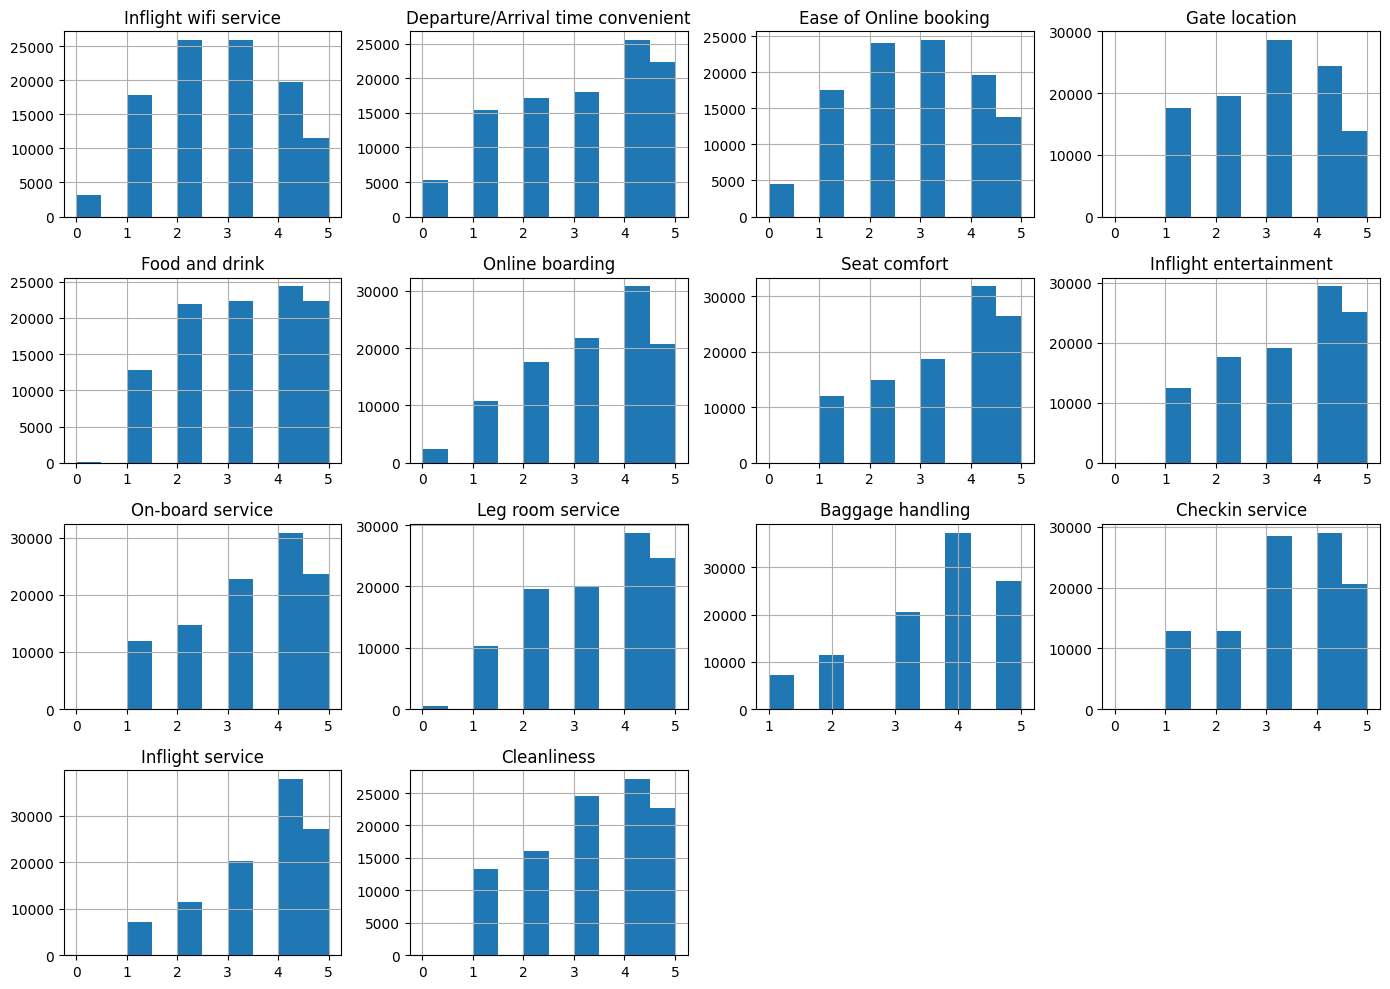

In [89]:
import matplotlib.pyplot as plt

X_cluster.hist(figsize=(14, 10))
plt.tight_layout()
plt.show()

In [90]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

print(X_scaled)

[[ 0.20357895  0.6161719   0.17377614 ...  0.5497986   1.15643582
   1.30586973]
 [ 0.20357895 -0.69524516  0.17377614 ... -1.82101248  0.30584786
  -1.74229153]
 [-0.54953343 -0.69524516 -0.54105962 ...  0.5497986   0.30584786
   1.30586973]
 ...
 [-1.30264581 -1.35095368 -1.25589538 ...  1.34006895  1.15643582
   0.54382941]
 [-1.30264581 -1.35095368 -1.25589538 ...  1.34006895  0.30584786
  -1.74229153]
 [-1.30264581 -0.03953663  0.17377614 ...  0.5497986  -0.54474009
  -1.74229153]]


In [91]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=service_cols
)

print(X_scaled_df.head())

   Inflight wifi service  Departure/Arrival time convenient  \
0               0.203579                           0.616172   
1               0.203579                          -0.695245   
2              -0.549533                          -0.695245   
3              -0.549533                           1.271880   
4               0.203579                          -0.039537   

   Ease of Online booking  Gate location  Food and drink  Online boarding  \
0                0.173776      -1.547323        1.352264        -0.185532   
1                0.173776       0.018094       -1.656326        -0.185532   
2               -0.541060      -0.764614        1.352264         1.296496   
3                1.603448       1.583511       -0.904178        -0.926545   
4                0.173776       0.018094        0.600117         1.296496   

   Seat comfort  Inflight entertainment  On-board service  Leg room service  \
0      1.183099                1.231704          0.479403          -0.26684   


In [92]:
print(X_scaled_df.describe())

       Inflight wifi service  Departure/Arrival time convenient  \
count           1.039040e+05                       1.039040e+05   
mean            6.024678e-17                      -1.620714e-16   
std             1.000005e+00                       1.000005e+00   
min            -2.055758e+00                      -2.006662e+00   
25%            -5.495334e-01                      -6.952452e-01   
50%             2.035790e-01                      -3.953663e-02   
75%             9.566913e-01                       6.161719e-01   
max             1.709804e+00                       1.271880e+00   

       Ease of Online booking  Gate location  Food and drink  Online boarding  \
count            1.039040e+05   1.039040e+05    1.039040e+05     1.039040e+05   
mean             1.427869e-16   3.638058e-17    1.518137e-16    -2.639643e-17   
std              1.000005e+00   1.000005e+00    1.000005e+00     1.000005e+00   
min             -1.970731e+00  -2.330031e+00   -2.408473e+00    -2.40857

In [93]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in [2, 3, 4, 5]:
    kmeans = KMeans(
        n_clusters=k,
        random_state=10,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        cluster_labels,
        sample_size=10000,
        random_state=10
    )

    scores.append([k, score])

    print(k, score)

2 0.18321863313306452
3 0.14897191630362655
4 0.14656011231011543
5 0.1313492865771968


In [94]:
score_df = pd.DataFrame(
    scores,
    columns=["k", "silhouette_score"]
)

print(score_df)

   k  silhouette_score
0  2          0.183219
1  3          0.148972
2  4          0.146560
3  5          0.131349


In [96]:
kmeans = KMeans(
    n_clusters=2,
    random_state=10,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

In [97]:
cluster_df = df.copy()

cluster_df["Cluster"] = cluster_labels

print(cluster_df[["Cluster"] + service_cols].head())

   Cluster  Inflight wifi service  Departure/Arrival time convenient  \
0        0                      3                                  4   
1        1                      3                                  2   
2        0                      2                                  2   
3        1                      2                                  5   
4        0                      3                                  3   

   Ease of Online booking  Gate location  Food and drink  Online boarding  \
0                       3              1               5                3   
1                       3              3               1                3   
2                       2              2               5                5   
3                       5              5               2                2   
4                       3              3               4                5   

   Seat comfort  Inflight entertainment  On-board service  Leg room service  \
0             5          

In [98]:
print(cluster_df["Cluster"].value_counts())

Cluster
0    57853
1    46051
Name: count, dtype: int64


In [99]:
cluster_mean = cluster_df.groupby("Cluster")[service_cols].mean()

print(cluster_mean.round(2))

         Inflight wifi service  Departure/Arrival time convenient  \
Cluster                                                             
0                         3.08                               3.17   
1                         2.29                               2.92   

         Ease of Online booking  Gate location  Food and drink  \
Cluster                                                          
0                          2.97           3.01            3.86   
1                          2.49           2.94            2.38   

         Online boarding  Seat comfort  Inflight entertainment  \
Cluster                                                          
0                   3.77          4.16                    4.27   
1                   2.60          2.53                    2.22   

         On-board service  Leg room service  Baggage handling  \
Cluster                                                         
0                    3.88              3.75              4.05  

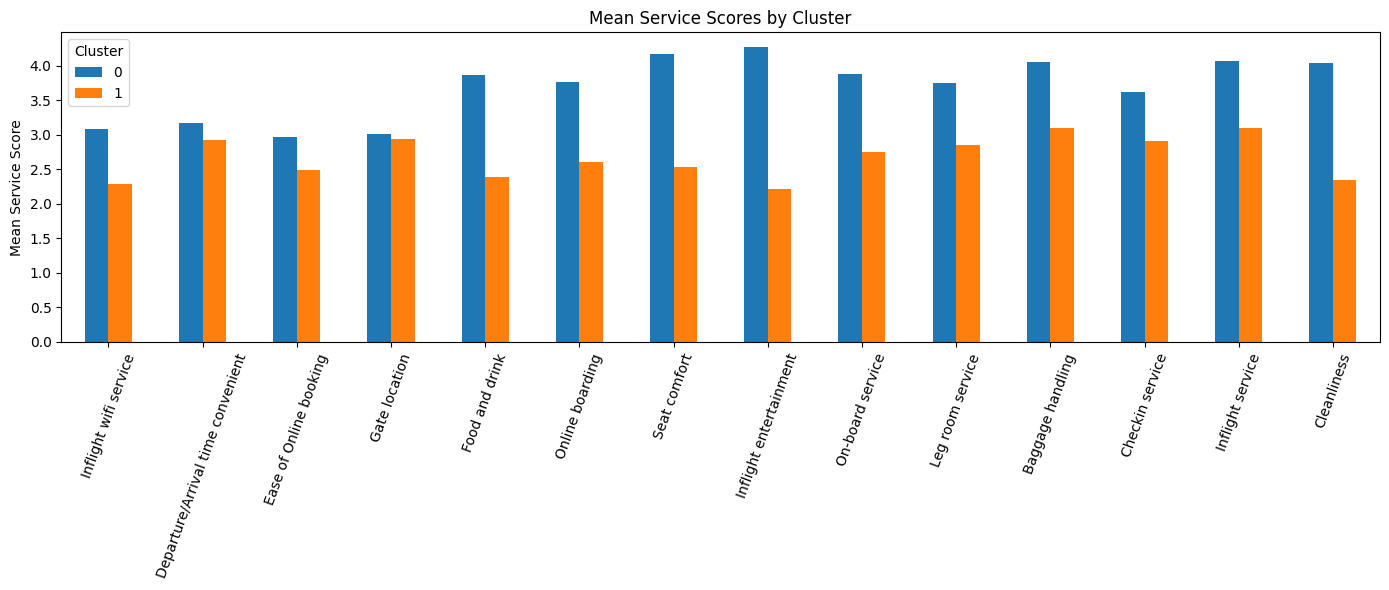

In [100]:
cluster_mean.T.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.ylabel("Mean Service Score")
plt.title("Mean Service Scores by Cluster")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

군집 번호 자체에는 의미 없음

따라서 각 군집의 전체 서비스 평균을 계산하여
어느 군집이 상대적으로 높은 서비스 평가를 보이는지 확인

In [101]:
cluster_score = cluster_mean.mean(axis=1)

print(cluster_score)

high_cluster = cluster_score.idxmax()
low_cluster = cluster_score.idxmin()

print()
print("서비스 평가가 높은 군집 :", high_cluster)
print("서비스 평가가 낮은 군집 :", low_cluster)

Cluster
0    3.692473
1    2.673201
dtype: float64

서비스 평가가 높은 군집 : 0
서비스 평가가 낮은 군집 : 1


## 군집별 실제 만족률 확인

`satisfaction`은 KMeans를 학습할 때 사용하지 않음

군집을 모두 만든 뒤,
각 군집에 실제 만족 승객이 얼마나 포함되어 있는지 확인하여 군집을 해석

In [102]:
satisfaction_by_cluster = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["satisfaction"],
    normalize="index"
) * 100

print(satisfaction_by_cluster.round(2))

satisfaction  neutral or dissatisfied  satisfied
Cluster                                         
0                               35.92      64.08
1                               82.73      17.27


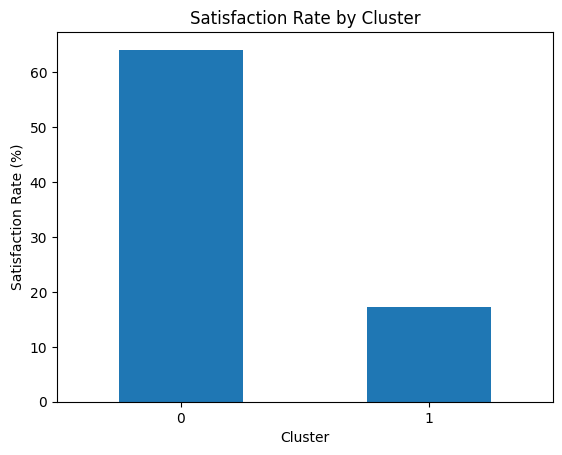

In [103]:
satisfaction_by_cluster["satisfied"].plot(
    kind="bar"
)

plt.ylabel("Satisfaction Rate (%)")
plt.title("Satisfaction Rate by Cluster")
plt.xticks(rotation=0)
plt.show()

군집은 서비스 평가로만 만들었지만,
각 군집에 어떤 승객들이 많이 포함되어 있는지 추가로 확인

In [104]:
travel_by_cluster = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Type of Travel"],
    normalize="index"
) * 100

print(travel_by_cluster.round(2))

Type of Travel  Business travel  Personal Travel
Cluster                                         
0                         74.71            25.29
1                         61.75            38.25


In [105]:
class_by_cluster = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Class"],
    normalize="index"
) * 100

print(class_by_cluster.round(2))

Class    Business    Eco  Eco Plus
Cluster                           
0           58.79  35.37      5.84
1           33.99  57.07      8.94


In [106]:
customer_by_cluster = pd.crosstab(
    cluster_df["Cluster"],
    cluster_df["Customer Type"],
    normalize="index"
) * 100

print(customer_by_cluster.round(2))

Customer Type  Loyal Customer  disloyal Customer
Cluster                                         
0                       85.64              14.36
1                       76.82              23.18


In [107]:
profile_mean = cluster_df.groupby("Cluster")[["Age", "Flight Distance"]].mean()

print(profile_mean.round(2))

           Age  Flight Distance
Cluster                        
0        40.53          1319.54
1        37.93          1026.02


In [108]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PCA1", "PCA2"]
)

pca_df["Cluster"] = cluster_labels

print(pca_df.head())

       PCA1      PCA2  Cluster
0  2.362768 -1.263450        0
1 -3.197085  1.282345        1
2  2.175759 -1.920269        0
3 -1.739995  2.523169        1
4  0.759819  0.214656        0


In [110]:
centers_pca = pca.transform(kmeans.cluster_centers_)

print(centers_pca)


[[ 1.45215249 -0.18081199]
 [-1.82388486  0.22709753]]


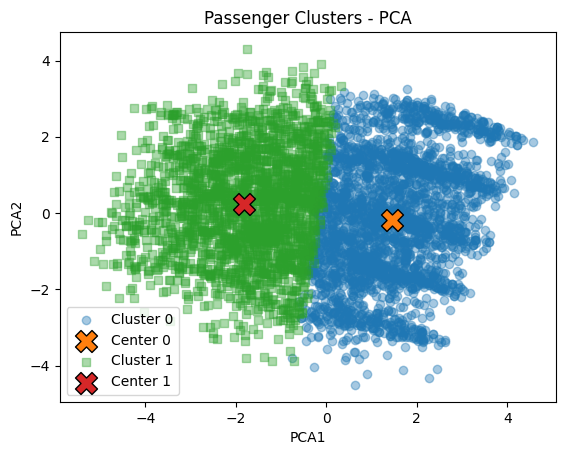

In [111]:
pca_sample = pca_df.sample(
    n=5000,
    random_state=10
)

markers = ["o", "s"]

for label in [0, 1]:
    cluster_data = pca_sample[
        pca_sample["Cluster"] == label
    ]

    plt.scatter(
        cluster_data["PCA1"],
        cluster_data["PCA2"],
        marker=markers[label],
        alpha=0.4,
        label=f"Cluster {label}"
    )

    plt.scatter(
        centers_pca[label][0],
        centers_pca[label][1],
        s=250,
        marker="X",
        edgecolor="black",
        label=f"Center {label}"
    )

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend()
plt.title("Passenger Clusters - PCA")
plt.show()


## 결과 해석

이 클러스터링은 승객의 `satisfaction` 정답을 사용하지 않고
14개의 서비스 평가만으로 승객을 두 집단으로 나눈 결과다

- **서비스 평가가 높은 군집**
  - Wi-Fi, 온라인 탑승, 좌석 편안함, 기내 서비스 등 전반적인 서비스 점수가 상대적으로 높음
  - 실제 만족 승객의 비율도 상대적으로 높게 나타나는지 확인

- **서비스 평가가 낮은 군집**
  - 여러 서비스 평가가 상대적으로 낮음
  - 실제 불만족/중립 승객의 비율이 상대적으로 높게 나타나는지 확인

### 분류 결과와의 연결

앞선 XGBoost + SHAP 분석에서는
`Inflight wifi service`, `Online boarding`, `Type of Travel`, `Customer Type`, `Class`
등이 만족 예측에서 중요한 변수로 나타났음

클러스터링에서는 정답을 사용하지 않고 서비스 평가만으로 승객을 묶었는데,
군집별 실제 만족률 차이가 나타난다면
**서비스 경험 패턴과 승객 만족이 서로 연결되어 있음을 보조적으로 확인할 수 있음**

단, 클러스터링 역시 인과관계를 의미하지 않음